### 1.Load data

In [ ]:
import scanpy as sc # cross celltype predict
import scresid
# import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('./data/kang.h5ad')
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [ ]:
adata = scresid.adata_process(adata, 
                      # n_top_genes=2000
                      )

In [3]:
adata.obs.rename(columns={"label": "condition"}, inplace=True) # kang
adata.obs["condition"].replace({"ctrl": "control"}, inplace=True)
adata.obs['condition'].replace({"stim": "stimulated"}, inplace=True)

In [4]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 24562 × 6000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes', 'n_counts'
    var: 'name', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

 condition
stimulated    12301
control       12261
Name: count, dtype: int64

 cell_type
CD4 T cells          11238
CD14+ Monocytes       5696
B cells               2651
NK cells              1716
CD8 T cells           1621
FCGR3A+ Monocytes     1089
Dendritic cells        529
Megakaryocytes          22
Name: count, dtype: int64


### 2.Build and train models

In [5]:
model = scresid.SCRESID(input_dim=adata.n_vars, device='cuda:0')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }


In [ ]:
cell_to_pred = 'CD4 T cells' # CD14+ Monocytes, B cells, NK cells, CD8 T cells, FCGR3A+ Monocytes, Dendritic cells, Megakaryocytes
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, batch_size=256, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


### 3.Predict

In [7]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.01 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of CD4 T cells and control...
Get adata of without CD4 T cells and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of CD4 T cells...
Compute cosine similarity with latent adata of CD4 T cells and control...
Select top control with ratio 0.01...
Normalize weights of 68 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 5560 × 6000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes', 'n_counts'
    var: 'name', 'n_cells', 'mean', 'std', 'highly_variable', '

### 4.Evaluation

PCA cluster results...


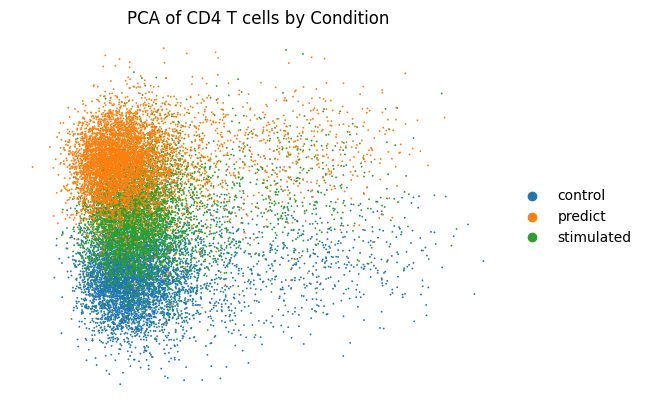

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  54
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


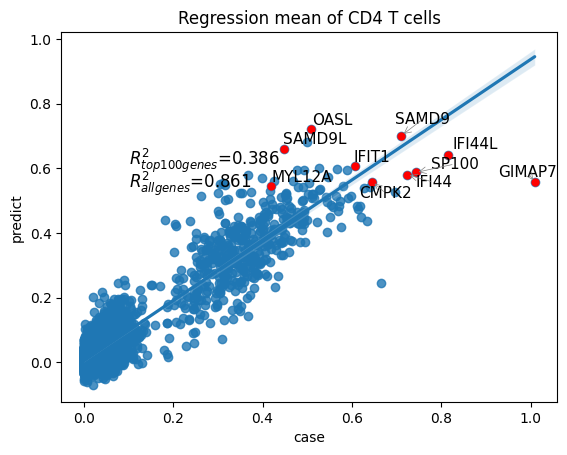

R2 mean of all genes 0.861, top genes 0.386
Regression plot of var...


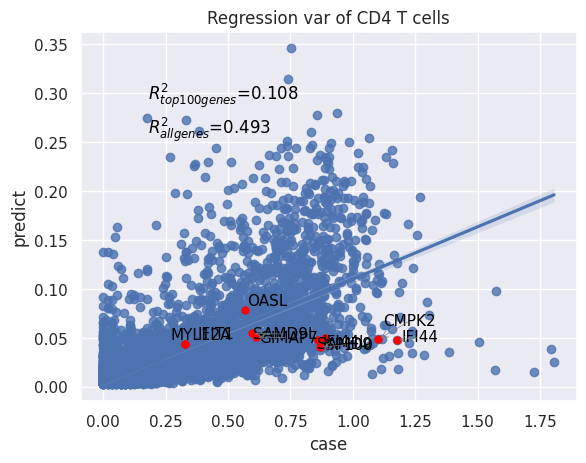

R2 var of all genes 0.493, top genes 0.108
Plot violin graph of first gene IFIT1...


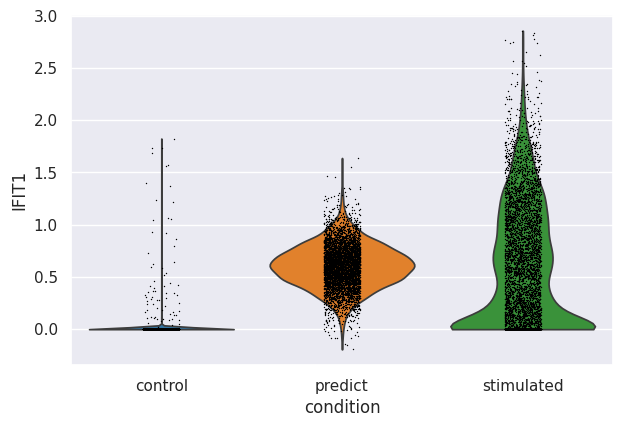

Plot violin graph of second gene IFI44L...


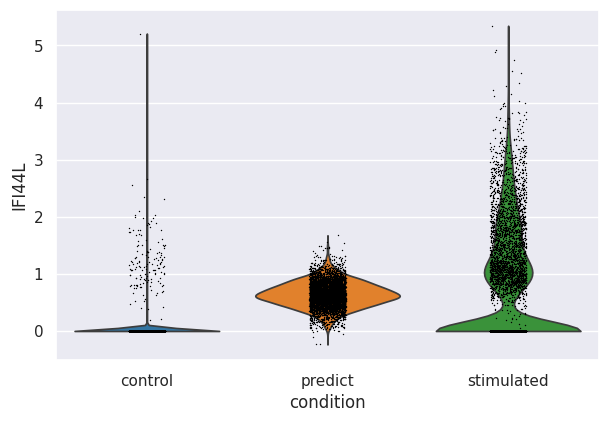

Plot violin graph of third gene OASL...


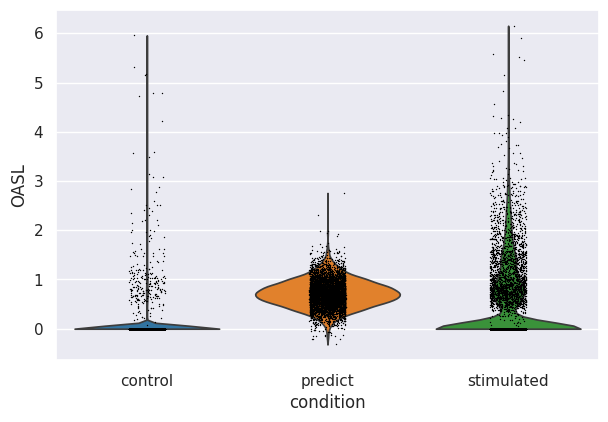

Compute DEGS contrast...
Plot 25 genes of eval_adata...


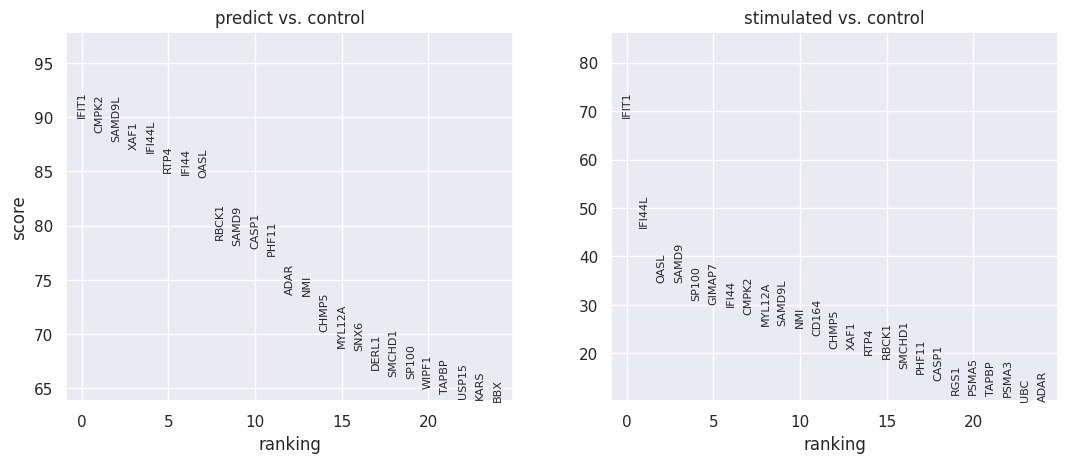

Dotplot of the first 20 genes...


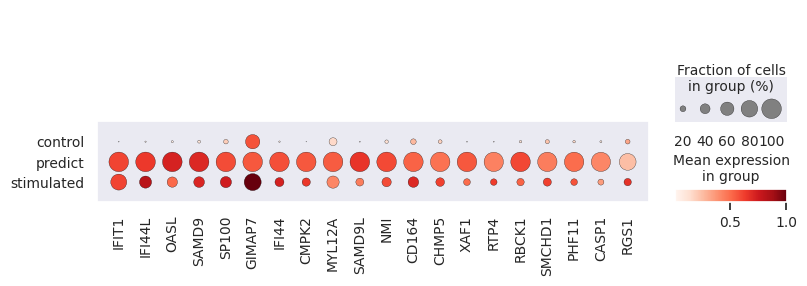

In [8]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                        cell_type=cell_to_pred, 
                        key_dic=key_dic
                        )
